In [ ]:
import os, ctypes
from glob import glob
append_ld_library_path = "~/.local/lib/python3.10/site-packages/nvidia/cublas/lib"
LD_LIBRARY_PATH = os.environ.get("LD_LIBRARY_PATH", "")
os.environ["LD_LIBRARY_PATH"] = f"{append_ld_library_path}:{LD_LIBRARY_PATH}" if LD_LIBRARY_PATH else append_ld_library_path

cublas_dir = "/home/ubuntu/.local/lib/python3.10/site-packages/nvidia/cublas/lib"
for pat in ["libcublas.so*", "libcublasLt.so*", "libcudart.so*"]:
    for lib in sorted(glob(os.path.join(cublas_dir, pat))):
        try:
            ctypes.CDLL(lib, mode=ctypes.RTLD_GLOBAL)
        except OSError as e:
            print(f"Warning: could not load {lib}: {e}")

import string
import numpy as np
import torch
import matplotlib.pyplot as plt
from typing import TypeVar, Callable, Optional, Sequence
from pathlib import Path
from tqdm import tqdm
from copy import deepcopy
from glob import glob

from poet.models.poet import PoET
from poet.alphabets import Uniprot21
from poet.msa.sampling import MSASampler, NeighborsSampler
from poet.fasta import parse_stream

import esm

ASCII_LOWERCASE_BYTES = string.ascii_lowercase.encode()
PBAR_POSITION = 1


T = TypeVar("T", np.ndarray, torch.Tensor)

# Import MSA Pairformer modules
from MSA_Pairformer.model import MSAPairformer
from MSA_Pairformer.dataset import aa2tok_d, prepare_msa_masks

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
torch.set_float32_matmul_precision('high')
print(f"Using device: {torch.cuda.get_device_name(device)}")

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.0
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/home/ubuntu/.local/lib/python3.10/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


Using device: NVIDIA GH200 480GB


In [2]:
# Also include the jac_to_con function from your code
def jac_to_con(jac, center=True, diag="remove", apc=True,
               symm_before=True, symm_after=False):
    """Convert Jacobian to contact map"""
    X = jac.copy()
    Lx, Ax, Ly, Ay = X.shape

    if symm_before:
        X = X + X.transpose(2, 3, 0, 1)

    if center:
        for i in range(4):
            if X.shape[i] > 1:
                X -= X.mean(i, keepdims=True)

    contacts = np.sqrt(np.square(X).sum((1, 3)))

    if symm_after:
        contacts = contacts + contacts.T

    if diag == "remove":
        np.fill_diagonal(contacts, 0)

    if diag == "normalize":
        contacts_diag = np.diag(contacts)
        contacts = contacts / np.sqrt(contacts_diag[:, None] * contacts_diag[None, :])

    if apc:
        ap = contacts.sum(0, keepdims=True) * contacts.sum(1, keepdims=True) / contacts.sum()
        contacts = contacts - ap

    if diag == "remove":
        np.fill_diagonal(contacts, 0)

    return contacts

# 1. MSA Pairformer

In [3]:
# Load model
model = MSAPairformer.from_pretrained(device=device).to(torch.bfloat16)
model = torch.compile(model, dynamic=True)

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

Using cuEquivariance for triangle multiplicative update


In [4]:
# Function to get logits for the first sequence
def get_logits(
    x,
    mask,
    msa_mask,
    full_mask,
    pairwise_mask,
    breaks,
    return_probs=False,
    return_seq_weights=False,
    seq_weights_dict=None,
):
    with torch.no_grad():
        with torch.amp.autocast(dtype=torch.bfloat16, device_type="cuda"):
            if seq_weights_dict is None:
                res = model(
                    msa=x.to(torch.bfloat16),
                    mask=mask,
                    msa_mask=msa_mask,
                    full_mask=full_mask,
                    pairwise_mask=pairwise_mask,
                    complex_chain_break_indices=[breaks] if breaks else None,
                    return_cb_contacts=False,
                    return_confind_contacts=False,
                    return_seq_weights=False,
                    query_only=True
                )
            else:
                res = model(
                    msa=x.to(torch.bfloat16),
                    mask=mask,
                    msa_mask=msa_mask,
                    full_mask=full_mask,
                    pairwise_mask=pairwise_mask,
                    seq_weights_dict=seq_weights_dict,
                    complex_chain_break_indices=[breaks] if breaks else None,
                    return_cb_contacts=False,
                    return_confind_contacts=False,
                    return_seq_weights=False,
                    query_only=True
                )
    # Get logits for first sequence, only amino acid tokens (0-19)
    seq_length = x.shape[2]
    logits = res["logits"][0, 0, :seq_length, :20].float()

    if return_probs:
        # Apply softmax to get probabilities
        probs = torch.nn.functional.softmax(logits, dim=-1)
        if return_seq_weights:
            return probs.cpu().numpy(), res["seq_weights_list_d"]
        else:
            return probs.cpu().numpy()
    else:
        if return_seq_weights:
            return logits.cpu().numpy(), res["seq_weights_list_d"]
        else:
            return logits.cpu().numpy()

def get_msa_pairformer_categorical_jacobian(
    msa_onehot_t,
    msa_tokenized_t,
    mask,
    msa_mask,
    full_mask,
    pairwise_mask,
    breaks,
    mutation_subset=None,
    show_progress=True
):
    # Get logits for unperturbed MSA
    fx, seq_weights_list_d = get_logits(msa_onehot_t, mask, msa_mask, full_mask, pairwise_mask, breaks, return_probs=False, return_seq_weights=True)  # (L, 20)

    # Get the wildtype sequence
    wt_sequence = msa_tokenized_t[0].cpu().numpy()  # Token indices

    # Parse mutation subset
    if mutation_subset is None:
        # Full Jacobian - all 20 amino acids
        mutation_indices = list(range(20))
    else:
        # Convert mutation subset to indices
        mutation_indices = []
        for mut in mutation_subset:
            if isinstance(mut, str):
                if mut.upper() in aa2tok_d:
                    mutation_indices.append(aa2tok_d[mut.upper()])
                else:
                    raise ValueError(f"Unknown amino acid: {mut}")
            else:
                # Assume it's already an index
                mutation_indices.append(int(mut))

    # Initialize Jacobian matrix
    print(mutation_indices)
    seq_length = msa_onehot_t.shape[2]
    fx_h = np.zeros((seq_length, len(mutation_indices), seq_length, 20))

    # Setup progress bar
    if show_progress:
        try:
            iterator = tqdm(range(seq_length), desc="Computing Jacobian")
        except ImportError:
            print("Computing Jacobian...")
            iterator = range(seq_length)
    else:
        iterator = range(seq_length)

    # For each residue position
    for n in iterator:
        # Get wildtype amino acid at this position
        wt_aa = wt_sequence[n]

        # Try specified mutations
        for idx, mutation_aa in tqdm(enumerate(mutation_indices)):
            # Skip computation for wildtype if in full mode
            if mutation_aa == wt_aa and mutation_subset is None:
                fx_h[n, idx] = fx.copy()
            else:
                # Compute mutation effect
                msa_h = msa_onehot_t.clone()
                msa_h[0, 0, n, :] = 0  # Clear one-hot
                msa_h[0, 0, n, mutation_aa] = 1  # Set to mutation
                fx_h[n, idx] = get_logits(msa_h, mask, msa_mask, full_mask, pairwise_mask, breaks, return_probs=False, seq_weights_dict=seq_weights_list_d)

    # Compute Jacobian: original - perturbed
    result = fx - fx_h
    return result

In [5]:
msa_file = "../../data/Figure3_toxin_antitoxin/ParDE_hhfilter.a3m"
chain_break_idx = 93
with open(msa_file, "r") as oFile:
        msa_str_l = oFile.readlines()[1::2]
msa_tokenized_t = np.array([list(seq.strip()) for seq in msa_str_l])
msa_tokenized_t = np.vectorize(aa2tok_d.get)(msa_tokenized_t)
msa_tokenized_t = torch.from_numpy(msa_tokenized_t)

# Prepare input and masks
msa_onehot_t = torch.nn.functional.one_hot(msa_tokenized_t, num_classes=len(aa2tok_d)).unsqueeze(0).to(torch.bfloat16).to(device)
mask, msa_mask, full_mask, pairwise_mask = prepare_msa_masks(msa_tokenized_t.unsqueeze(0))
mask, msa_mask, full_mask, pairwise_mask = mask.to(device), msa_mask.to(device), full_mask.to(device), pairwise_mask.to(device)
    
result = get_msa_pairformer_categorical_jacobian(
    msa_onehot_t,
    msa_tokenized_t,
    mask,
    msa_mask,
    full_mask,
    pairwise_mask,
    [chain_break_idx]
)
con = jac_to_con(result)
np.savetxt(f"results/msa_pairformer_toxin_antitoxin_jacobian.txt", con)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


20it [00:02,  7.97it/s]%|          | 0/196 [00:00<?, ?it/s]
20it [00:02,  7.97it/s]%|          | 1/196 [00:02<08:09,  2.51s/it]
20it [00:02,  7.98it/s]%|          | 2/196 [00:05<08:06,  2.51s/it]
20it [00:02,  7.98it/s]%|▏         | 3/196 [00:07<08:04,  2.51s/it]
20it [00:02,  7.99it/s]%|▏         | 4/196 [00:10<08:01,  2.51s/it]
20it [00:02,  7.94it/s]%|▎         | 5/196 [00:12<07:58,  2.51s/it]
20it [00:02,  7.95it/s]%|▎         | 6/196 [00:15<07:57,  2.51s/it]
20it [00:02,  7.98it/s]%|▎         | 7/196 [00:17<07:55,  2.51s/it]
20it [00:02,  7.98it/s]%|▍         | 8/196 [00:20<07:52,  2.51s/it]
20it [00:02,  7.98it/s]%|▍         | 9/196 [00:22<07:49,  2.51s/it]
20it [00:02,  7.97it/s]%|▌         | 10/196 [00:25<07:46,  2.51s/it]
20it [00:02,  7.97it/s]%|▌         | 11/196 [00:27<07:44,  2.51s/it]
20it [00:02,  7.95it/s]%|▌         | 12/196 [00:30<07:42,  2.51s/it]
20it [00:02,  7.94it/s]%|▋         | 13/196 [00:32<07:39,  2.51s/it]
20it [00:02,  7.94it/s]%|▋         | 14/196 [00:35<0

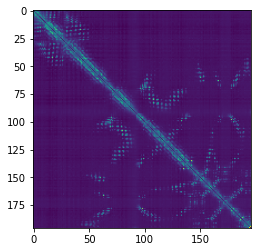

In [6]:
plt.imshow(con)

# 2. PoET

In [3]:
# Load the model checkpoint
ckpt_path = "../../../PoET/data/poet.ckpt"  # PoET root directory
ckpt = torch.load(ckpt_path)

# Initialize model with checkpoint hyperparameters
model = PoET(**ckpt["hyper_parameters"]["model_spec"]["init_args"])

# Load the trained weights
model.load_state_dict({
    k.split(".", 1)[1]: v for k, v in ckpt["state_dict"].items()
})

# Set up for inference
model = model.cuda().half().eval()

# Create alphabet
alphabet = Uniprot21(
    include_gap=True, 
    include_startstop=True, 
    distinct_startstop=True
)

# Optional: JIT warmup (from scoring script)
def jit_warmup(model, alphabet):
    x = b"$WAAAGH*$WAAGW*"
    segment_sizes = [8, 7]
    x = alphabet.encode(x)
    x = torch.from_numpy(x).long().cuda()
    segment_sizes = torch.tensor(segment_sizes).long().cuda()
    _ = model.embed(x.unsqueeze(0), segment_sizes.unsqueeze(0))

jit_warmup(model, alphabet)

/tmp/ipykernel_2471097/2787319139.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path)


In [4]:
def get_poet_categorical_jacobian(msa_sequences, alphabet, model):
    
    def append_startstop(x, alphabet):
        if isinstance(x, str):
            x = alphabet.encode(x.encode())
        x_ = np.empty(len(x) + 2, dtype=x.dtype)
        x_[0] = alphabet.start_token
        x_[-1] = alphabet.stop_token
        x_[1:-1] = x
        return x_
    
    def compute_jacobian():
        sequences = msa_sequences.copy()
        
        encoded_seqs = []
        for seq in sequences:
            encoded = alphabet.encode(seq.encode())
            encoded_with_tokens = append_startstop(encoded, alphabet)
            encoded_seqs.append(encoded_with_tokens)
        
        target_seq = encoded_seqs[0]
        target_aa_len = len(target_seq) - 2
        msa_seqs = encoded_seqs[1:]
        
        device = next(model.parameters()).device
        
        if msa_seqs:
            segment_sizes = torch.tensor([len(s) for s in msa_seqs]).cuda()
            msa_concat = torch.cat([torch.from_numpy(s).long() for s in msa_seqs]).cuda()
            memory = model.embed(msa_concat.unsqueeze(0), segment_sizes.unsqueeze(0))
        else:
            memory = None
        
        with torch.no_grad():
            target_tensor = torch.from_numpy(target_seq).long().unsqueeze(0).to(device)
            baseline_logits = model.logits(target_tensor[:, :-1], memory)
            fx = baseline_logits[0, :target_aa_len, :20]
            
            jacobian = torch.zeros((target_aa_len, 20, target_aa_len, 20), device=device)
            
            for pos in tqdm(range(target_aa_len)):
                token_pos = pos + 1
                original_token = target_seq[token_pos]
                
                for aa_idx in range(20):
                    if aa_idx == original_token:
                        continue
                    
                    mutant_seq = target_seq.copy()
                    mutant_seq[token_pos] = aa_idx
                    mutant_tensor = torch.from_numpy(mutant_seq).long().unsqueeze(0).to(device)

                    
                    mutant_logits = model.logits(mutant_tensor[:, :-1], memory)
                    fx_mutant = mutant_logits[0, :target_aa_len, :20]
                    
                    jacobian[pos, aa_idx] = fx - fx_mutant
            
            return jacobian.cpu().numpy()
    
    return compute_jacobian()

In [9]:
# Also include the jac_to_con function from your code
def jac_to_con(jac, center=True, diag="remove", apc=True,
               symm_before=True, symm_after=False):
    """Convert Jacobian to contact map"""
    X = jac.copy()
    Lx, Ax, Ly, Ay = X.shape

    if symm_before:
        X = X + X.transpose(2, 3, 0, 1)

    if center:
        for i in range(4):
            if X.shape[i] > 1:
                X -= X.mean(i, keepdims=True)

    contacts = np.sqrt(np.square(X).sum((1, 3)))

    if symm_after:
        contacts = contacts + contacts.T

    if diag == "remove":
        np.fill_diagonal(contacts, 0)

    if diag == "normalize":
        contacts_diag = np.diag(contacts)
        contacts = contacts / np.sqrt(contacts_diag[:, None] * contacts_diag[None, :])

    if apc:
        ap = contacts.sum(0, keepdims=True) * contacts.sum(1, keepdims=True) / contacts.sum()
        contacts = contacts - ap

    if diag == "remove":
        np.fill_diagonal(contacts, 0)

    return contacts

def load_a3m_sequences(a3m_path):
    """Load sequences from a3m file using PoET's parser"""
    sequences = []
    with open(a3m_path, 'rb') as f:
        for header, seq in parse_stream(f, upper=False):
            # seq is already bytes, decode to string
            sequences.append(seq.decode('utf-8'))
    return sequences

In [6]:
def append_startstop(x: T, alphabet: Uniprot21) -> T:
    x_ndim = x.ndim
    assert x_ndim in {1, 2}
    if x_ndim == 1:
        x = x[None, :]

    if isinstance(x, torch.Tensor):
        empty_func = torch.empty
    else:
        empty_func = np.empty
    x_ = empty_func((x.shape[0], x.shape[1] + 2), dtype=x.dtype)
    x_[:, 0] = alphabet.start_token
    x_[:, -1] = alphabet.stop_token
    x_[:, 1:-1] = x
    if x_ndim == 1:
        x_ = x_.flatten()
    return x_

def get_seqs_from_fastalike(filepath: Path) -> list[bytes]:
    return [s for _, s in parse_stream(open(filepath, "rb"), upper=False)]

def get_encoded_msa_from_a3m_seqs(
    msa_sequences: list[bytes], alphabet: Uniprot21
) -> np.ndarray:
    return np.vstack(
        [
            alphabet.encode(s.translate(None, delete=ASCII_LOWERCASE_BYTES))
            for s in msa_sequences
        ]
    )

def sample_msa_sequences(
    get_sequence_fn: Callable[[int], bytes],
    sample_idxs: Sequence[int],
    max_tokens: int,
    alphabet: Uniprot21,
    shuffle: bool = True,
    shuffle_seed: Optional[int] = None,
    truncate: bool = True,
) -> list[np.ndarray]:
    assert alphabet.start_token != -1
    assert alphabet.stop_token != -1
    if not shuffle:
        assert shuffle_seed is None

    seqs, total_tokens = [], 0
    for idx in sample_idxs:
        next_sequence = get_sequence_fn(idx)
        seqs.append(append_startstop(alphabet.encode(next_sequence), alphabet=alphabet))
        total_tokens += len(seqs[-1])
        if total_tokens > max_tokens:
            break

    # shuffle order and truncate to max tokens
    if shuffle:
        rng = (
            np.random.default_rng(shuffle_seed)
            if shuffle_seed is not None
            else np.random
        )
        final_permutation = rng.permutation(len(seqs))
    else:
        final_permutation = np.arange(len(seqs))
    final_seqs, total_tokens = [], 0
    for seq in [seqs[i] for i in final_permutation]:
        if truncate and (total_tokens + len(seq) > max_tokens):
            seq = seq[: max_tokens - total_tokens]
        total_tokens += len(seq)
        final_seqs.append(seq)
        if total_tokens >= max_tokens:
            break
    return final_seqs

100%|██████████| 196/196 [01:40<00:00,  1.95it/s]


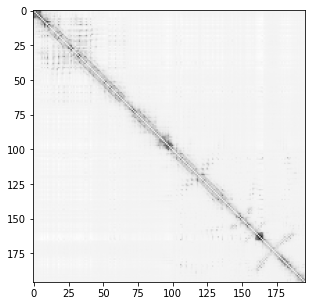

In [7]:
max_tokens = 24576
max_similarity = 0.9
seed = 188257
msa_a3m_path = "../../data/Figure3_toxin_antitoxin/ParDE_hhfilter.a3m"
msa_sequences = get_seqs_from_fastalike(msa_a3m_path)
msa = get_encoded_msa_from_a3m_seqs(msa_sequences=msa_sequences, alphabet=alphabet)
sampler = MSASampler(
    method=NeighborsSampler(
        can_use_torch=False,
    ),
    max_similarity=max_similarity,
)
sample_idxs = sampler.get_sample_idxs(
    msa=msa,
    gap_token=alphabet.gap_token,
    seed=seed,
)
# create the sequence-of-sequences
this_msa_sequences = sample_msa_sequences(
    get_sequence_fn=lambda ii: msa_sequences[ii]
    .upper()
    .translate(None, delete=b"-"),
    sample_idxs=sample_idxs,
    max_tokens=max_tokens,
    alphabet=alphabet,
    shuffle_seed=seed,
    truncate=False,
)
msa_sequences_l = [alphabet.decode(s).decode('utf-8')[1:-1] for s in this_msa_sequences]

# Get query sequence
with open(msa_a3m_path, 'r') as f:
    query_seq = f.readlines()[1].strip()
assert query_seq not in msa_sequences_l

msa_sequences_l = [query_seq] + msa_sequences_l

# Compute jacobian
jac = get_poet_categorical_jacobian(
    msa_sequences=msa_sequences_l,
    alphabet=alphabet,
    model=model
)

# Convert to contact map
con = jac_to_con(jac)

# Plot contact map
f, ax = plt.subplots(figsize=(5, 5))
ax.imshow(con, cmap='Greys')
np.savetxt("results/poet_toxin_antitoxin_jacobian.txt", con)

# MSA Transformer

In [3]:
# Load model
model_path = "/home/ubuntu/esm_models/esm_msa1b_t12_100M_UR50S.pt"
msa_transformer, msa_transformer_alphabet = esm.pretrained.load_model_and_alphabet_local(model_path)
msa_transformer = msa_transformer.eval().to(torch.float16).cuda()
msa_transformer = torch.compile(msa_transformer, dynamic=True)
msa_transformer_batch_converter = msa_transformer_alphabet.get_batch_converter()
total_params = sum(p.numel() for p in msa_transformer.parameters())
print(f"Total number of parameters: {total_params:,}")

/home/ubuntu/.local/lib/python3.10/site-packages/esm/pretrained.py:70: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_data = torch.load(str(model_location), map_locatio

Total number of parameters: 115,616,434


In [6]:
# Load MSA
parde_alignment_path = "../../data/Figure3_toxin_antitoxin/ParDE_hhfilter.a3m"
with open(parde_alignment_path, "r") as oFile:
    msa_str_l = oFile.readlines()[1::2]
msa_str_l = [(seq_idx, seq.strip()) for seq_idx, seq in enumerate(msa_str_l)]
# Prep MSA Transformer inputs
batch_labels, batch_strs, batch_tokens = msa_transformer_batch_converter([msa_str_l])
wt_tokens = deepcopy(batch_tokens[0, 0])
batch_tokens = batch_tokens.to(device)

In [7]:
def get_msa_transformer_logits(
    batch_tokens,
    return_probs=False
):
    with torch.no_grad():
        res = msa_transformer(batch_tokens)
    # Get logits for first sequence, only amino acid tokens (0-19)
    seq_length = batch_tokens.shape[2] - 1
    logits = res["logits"][0, 0, 1:seq_length+1, 4:24].float()

    if return_probs:
        # Apply softmax to get probabilities
        probs = torch.nn.functional.softmax(logits, dim=-1)
        return probs.cpu().numpy()
    else:
        return logits.cpu().numpy()

def get_msa_transformer_categorical_jacobian(
    batch_tokens,
    mutation_subset=None,
    show_progress=True
):
    # Get logits for unperturbed MSA
    fx = get_msa_transformer_logits(batch_tokens, return_probs=False)  # (L, 20)

    # Get the wildtype sequence
    wt_sequence = batch_tokens[0][0].cpu().numpy()

    # Parse mutation subset
    if mutation_subset is None:
        # Full Jacobian - all 20 amino acids
        mutation_indices = list(range(4, 24))
    else:
        # Convert mutation subset to indices
        mutation_indices = []
        for mut in mutation_subset:
            if isinstance(mut, str):
                if mut.upper() in msa_transformer_alphabet.tok_to_idx:
                    mutation_indices.append(msa_transformer_alphabet.tok_to_idx[mut.upper()])
                else:
                    raise ValueError(f"Unknown amino acid: {mut}")
            else:
                # Assume it's already an index
                mutation_indices.append(int(mut))

    # Initialize Jacobian matrix
    print(mutation_indices)
    seq_length = batch_tokens.shape[2] - 1
    fx_h = np.zeros((seq_length, len(mutation_indices), seq_length, 20))

    # Setup progress bar
    if show_progress:
        try:
            iterator = tqdm(range(1, seq_length+1), desc="Computing Jacobian")
        except ImportError:
            print("Computing Jacobian...")
            iterator = range(1, seq_length+1)
    else:
        iterator = range(1, seq_length+1)

    # For each residue position
    for n in iterator:
        # Get wildtype amino acid at this position
        wt_aa = wt_sequence[n]

        # Try specified mutations
        for idx, mutation_aa in tqdm(enumerate(mutation_indices)):
            # Skip computation for wildtype if in full mode
            if mutation_aa == wt_aa and mutation_subset is None:
                fx_h[n-1, idx] = fx.copy()
            else:
                # Compute mutation effect
                batch_tokens_h = deepcopy(batch_tokens)
                batch_tokens_h[0, 0, n] = mutation_aa
                fx_h[n-1, idx] = get_msa_transformer_logits(batch_tokens_h, return_probs=False)

    # Compute Jacobian: original - perturbed
    result = fx - fx_h
    return result

In [ ]:
res = get_msa_transformer_categorical_jacobian(batch_tokens)
con = jac_to_con(res)
np.savetxt(f"results/msa_transformer_toxin_antitoxin_jacobian.txt", con)

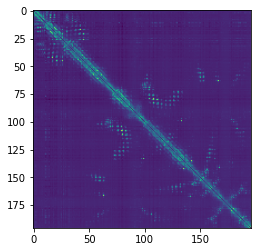

In [12]:
plt.imshow(con)